# XGBoost pathogenicity model

Gene-grouped train/valid/test split via `src/split_train_valid_test.py`, then an XGBoost
baseline on all structured features from the position-matched ClinVar–UniProt table.

Target: `label` (pathogenic vs benign). Genes never appear in more than one split.

In [5]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from xgboost import XGBClassifier

In [6]:
load_dotenv()
project_root = Path(os.environ["PROJECT_ROOT"])
sys.path.insert(0, str(project_root / "src"))

from split_train_valid_test import (
    CATEGORICAL_FEATURES,
    FEATURE_COLUMNS,
    build_feature_matrix,
    run_split,
    split_summary,
)

MODELS_DIR = project_root / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

## Train / valid / test split

Calls `run_split()` from `src/split_train_valid_test.py` (same entry point as
`python src/split_train_valid_test.py`). Writes `data/processed/{train,valid,test}.parquet`.

In [7]:
frames = run_split()
train_df, valid_df, test_df = frames["train"], frames["valid"], frames["test"]
combined = pd.concat([train_df, valid_df, test_df], ignore_index=True)
split_summary(combined)

,split,n_variants,n_genes,pct_pathogenic,pct_with_protein_position
0,train,8094,52,52.792192,75.475661
1,valid,1735,43,58.789625,81.959654
2,test,1734,42,61.072664,85.755479


In [8]:
train_genes = set(train_df["gene"])
valid_genes = set(valid_df["gene"])
test_genes = set(test_df["gene"])
assert train_genes.isdisjoint(valid_genes)
assert train_genes.isdisjoint(test_genes)
assert valid_genes.isdisjoint(test_genes)

print(f"features ({len(FEATURE_COLUMNS)}):")
for col in FEATURE_COLUMNS:
    print(f"  - {col}")

features (22):
  - Length
  - protein_position
  - relative_protein_position
  - distance_to_closest_feature
  - has_protein_position
  - in_domain
  - in_region
  - in_zinc_finger
  - in_active_site
  - in_binding_site
  - in_disulfide
  - in_mod_res
  - in_functional_site
  - in_any_feature
  - closest_feature_type
  - closest_feature_description
  - domain_names
  - region_names
  - Chromosome
  - ReferenceAlleleVCF
  - AlternateAlleleVCF
  - OriginSimple


## Feature matrices

Category levels are taken from **train only**. Values unseen at valid/test
time are mapped to `__MISSING__` so evaluation stays leak-free.


In [9]:
X_train, y_train = build_feature_matrix(train_df)
X_valid, y_valid = build_feature_matrix(valid_df)
X_test, y_test = build_feature_matrix(test_df)


def align_categories_to_train(
    train: pd.DataFrame, *others: pd.DataFrame
) -> tuple[pd.DataFrame, ...]:
    train = train.copy()
    others = [f.copy() for f in others]
    for col in CATEGORICAL_FEATURES:
        cats = list(train[col].cat.categories)
        if "__MISSING__" not in cats:
            cats = cats + ["__MISSING__"]
        train[col] = train[col].cat.set_categories(cats)
        for frame in others:
            values = frame[col].astype("string")
            values = values.where(values.isin(cats), "__MISSING__")
            frame[col] = pd.Categorical(values, categories=cats)
    return (train, *others)


X_train, X_valid, X_test = align_categories_to_train(X_train, X_valid, X_test)
print(X_train.shape, X_valid.shape, X_test.shape)
print("pathogenic rates:", y_train.mean().round(3), y_valid.mean().round(3), y_test.mean().round(3))


(8094, 22) (1735, 22) (1734, 22)
pathogenic rates: 0.528 0.588 0.611


## Fit XGBoost

Early stopping on validation ROC-AUC. Native categorical support (`enable_categorical=True`).

In [10]:
model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=5,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="auc",
    enable_categorical=True,
    tree_method="hist",
    random_state=42,
    n_jobs=4,
    early_stopping_rounds=50,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False,
)

print(f"best_iteration={model.best_iteration}, best_score={model.best_score:.4f}")

best_iteration=483, best_score=0.6165


## Evaluation

In [11]:
def evaluate(name: str, y_true: pd.Series, proba: np.ndarray, threshold: float = 0.5) -> dict:
    pred = (proba >= threshold).astype(int)
    metrics = {
        "split": name,
        "n": len(y_true),
        "roc_auc": roc_auc_score(y_true, proba),
        "pr_auc": average_precision_score(y_true, proba),
        "accuracy": (pred == y_true).mean(),
    }
    print(f"\n=== {name} ===")
    print(
        f"ROC-AUC={metrics['roc_auc']:.3f}  PR-AUC={metrics['pr_auc']:.3f}  "
        f"accuracy@{threshold}={metrics['accuracy']:.3f}"
    )
    print(classification_report(y_true, pred, target_names=["benign", "pathogenic"], digits=3))
    return metrics


proba_train = model.predict_proba(X_train)[:, 1]
proba_valid = model.predict_proba(X_valid)[:, 1]
proba_test = model.predict_proba(X_test)[:, 1]

metrics_table = pd.DataFrame(
    [
        evaluate("train", y_train, proba_train),
        evaluate("valid", y_valid, proba_valid),
        evaluate("test", y_test, proba_test),
    ]
).set_index("split")
metrics_table.round(3)


=== train ===
ROC-AUC=0.938  PR-AUC=0.944  accuracy@0.5=0.865
              precision    recall  f1-score   support

      benign      0.883     0.823     0.852      3821
  pathogenic      0.851     0.902     0.876      4273

    accuracy                          0.865      8094
   macro avg      0.867     0.863     0.864      8094
weighted avg      0.866     0.865     0.865      8094


=== valid ===
ROC-AUC=0.555  PR-AUC=0.622  accuracy@0.5=0.610
              precision    recall  f1-score   support

      benign      0.581     0.192     0.288       715
  pathogenic      0.614     0.903     0.731      1020

    accuracy                          0.610      1735
   macro avg      0.597     0.547     0.510      1735
weighted avg      0.600     0.610     0.549      1735


=== test ===
ROC-AUC=0.668  PR-AUC=0.744  accuracy@0.5=0.647
              precision    recall  f1-score   support

      benign      0.593     0.296     0.395       675
  pathogenic      0.660     0.871     0.751      

,n,roc_auc,pr_auc,accuracy
split,,,,
train,8094,0.938,0.944,0.865
valid,1735,0.555,0.622,0.610
test,1734,0.668,0.744,0.647


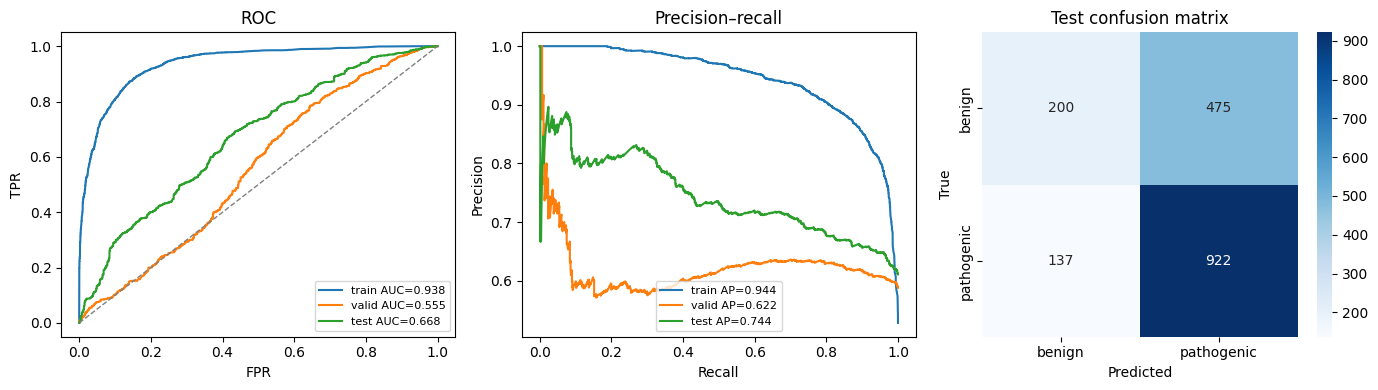

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for name, y_true, proba in [
    ("train", y_train, proba_train),
    ("valid", y_valid, proba_valid),
    ("test", y_test, proba_test),
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    axes[0].plot(fpr, tpr, label=f"{name} AUC={roc_auc_score(y_true, proba):.3f}")
    prec, rec, _ = precision_recall_curve(y_true, proba)
    axes[1].plot(rec, prec, label=f"{name} AP={average_precision_score(y_true, proba):.3f}")

axes[0].plot([0, 1], [0, 1], ls="--", c="gray", lw=1)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("ROC")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–recall")
axes[1].legend(fontsize=8)

cm = confusion_matrix(y_test, (proba_test >= 0.5).astype(int))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["benign", "pathogenic"],
    yticklabels=["benign", "pathogenic"],
    ax=axes[2],
)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")
axes[2].set_title("Test confusion matrix")

fig.tight_layout()
plt.show()

## Feature importance

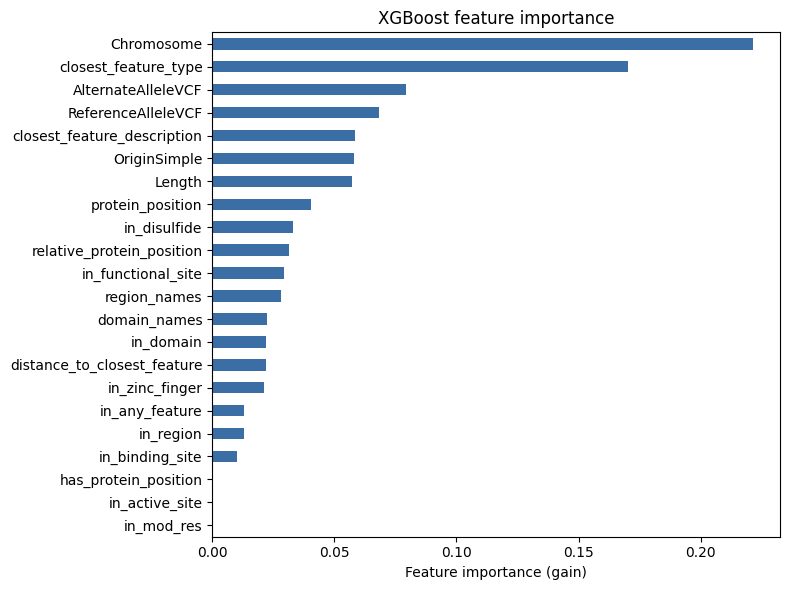

,gain
Chromosome,0.221384
closest_feature_type,0.170052
AlternateAlleleVCF,0.079199
ReferenceAlleleVCF,0.068404
closest_feature_description,0.058389
OriginSimple,0.058045
Length,0.057351
protein_position,0.040574
in_disulfide,0.032954
relative_protein_position,0.031615


In [13]:
importance = (
    pd.Series(model.feature_importances_, index=FEATURE_COLUMNS, name="gain")
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
importance.sort_values().plot.barh(ax=ax, color="#3b6ea5")
ax.set_xlabel("Feature importance (gain)")
ax.set_title("XGBoost feature importance")
fig.tight_layout()
plt.show()

importance.to_frame()

## Persist model

In [14]:
model_path = MODELS_DIR / "xgb_pathogenicity.json"
model.save_model(model_path)
print("Saved", model_path)
metrics_table.round(3)

Saved /home/milijanas/projects/clinvar-pathogenicity-classifier/models/xgb_pathogenicity.json


,n,roc_auc,pr_auc,accuracy
split,,,,
train,8094,0.938,0.944,0.865
valid,1735,0.555,0.622,0.610
test,1734,0.668,0.744,0.647
